# Deteccion del Marco del Sudoku con YOLO

Notebook de desarrollo del **detector del tablero**: dada una foto, YOLO localiza el marco del sudoku completo (1 clase).

- **Kernel:** `py312_arm` (Python 3.12, arm64) con **MPS** (GPU de Apple Silicon)
- Modulo: [`src/detector.py`](../src/detector.py) | Dataset: [`data/sudoku.yaml`](../data/sudoku.yaml)
- Datos reales (Roboflow) en `desarrollo_clase/`: 170 train / 21 val / 22 test.

Pasos: ver el dataset -> entrenar YOLO -> metricas -> probar la deteccion en fotos reales.

## 0. Entorno

In [1]:
import sys, os, glob
from pathlib import Path
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import ultralytics

sys.path.insert(0, os.path.abspath("../src"))
import detector

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("ultralytics", ultralytics.__version__, "| torch", torch.__version__, "| device:", DEVICE)

def show(img, title="", ax=None):
    ax = ax or plt.gca()
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(title); ax.axis("off")

ultralytics 8.4.69 | torch 2.12.0 | device: mps


## 1. Ver el dataset

Cada imagen tiene un `.txt` con la caja del tablero en formato YOLO (`clase cx cy w h`, normalizado). Dibujamos la caja de verdad (ground-truth) sobre unas imagenes de entrenamiento.

imagenes de entrenamiento: 170


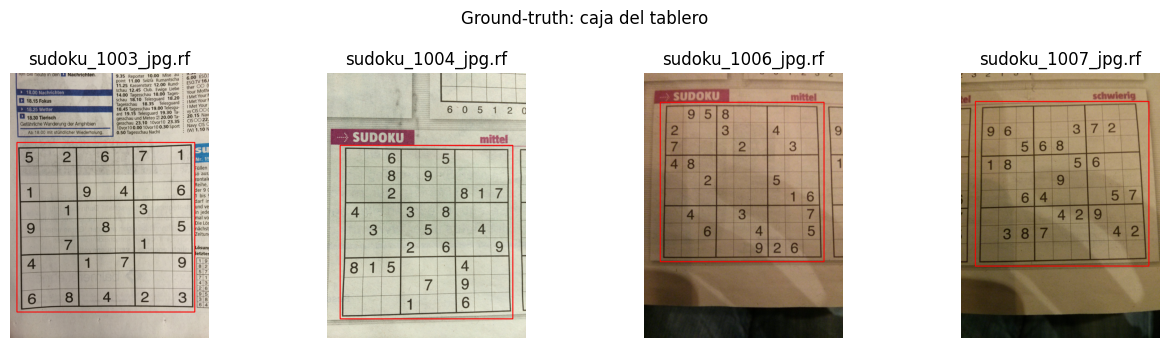

In [2]:
ROOT = Path("../data")

def draw_yolo_label(img, label_path):
    h, w = img.shape[:2]
    out = img.copy()
    if Path(label_path).exists():
        for line in Path(label_path).read_text().strip().splitlines():
            _, cx, cy, bw, bh = map(float, line.split())
            x1, y1 = int((cx - bw / 2) * w), int((cy - bh / 2) * h)
            x2, y2 = int((cx + bw / 2) * w), int((cy + bh / 2) * h)
            cv2.rectangle(out, (x1, y1), (x2, y2), (0, 0, 255), 4)
    return out

train_imgs = sorted(glob.glob(str(ROOT / "images/train/*.jpg")))
print("imagenes de entrenamiento:", len(train_imgs))
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, p in zip(axes, train_imgs[:4]):
    img = cv2.imread(p)
    lbl = str(ROOT / "labels/train" / (Path(p).stem + ".txt"))
    show(draw_yolo_label(img, lbl), Path(p).name[:18], ax)
plt.suptitle("Ground-truth: caja del tablero"); plt.tight_layout(); plt.show()

## 2. Entrenar YOLO

Usamos `detector.train_detector`, que internamente hace `YOLO(modelo).train(...)` sobre `data/sudoku.yaml` y copia el mejor checkpoint a `models/sudoku_detector.pt`. Partimos del `yolov8n.pt` ya descargado. Corre en **MPS** (GPU).

In [3]:
weights_path, results = detector.train_detector(
    base_model="../models/yolov8n.pt",
    epochs=60, imgsz=640, batch=16, device=DEVICE,
    name="sudoku_detector", patience=15,
)
print("\nModelo guardado en:", weights_path)

New https://pypi.org/project/ultralytics/8.4.71 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.12.0 MPS (Apple M5)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/nora/Documentos_Clase/BOOTCAMP/sudoku/data/sudoku.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=../desarrollo_clase/yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sudoku_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspective=0.0, plots

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8it/s 0.6s

                   all         21         21      0.998          1      0.995      0.991


Speed: 0.1ms preprocess, 7.0ms inference, 0.0ms loss, 3.0ms postprocess per image


Results saved to /Users/nora/runs/detect/sudoku_detector


Mejor modelo copiado a: /Users/nora/Documentos_Clase/BOOTCAMP/sudoku/models/sudoku_detector.pt

Modelo guardado en: /Users/nora/Documentos_Clase/BOOTCAMP/sudoku/models/sudoku_detector.pt


## 3. Metricas en validacion

`mAP50` (0-1): solapamiento de las cajas con un umbral del 50%. Cerca de 1 = deteccion casi perfecta.

In [4]:
m = results.box
print(f"Precision : {m.mp:.3f}")
print(f"Recall    : {m.mr:.3f}")
print(f"mAP50     : {m.map50:.3f}")
print(f"mAP50-95  : {m.map:.3f}")

Precision : 0.998
Recall    : 1.000
mAP50     : 0.995
mAP50-95  : 0.991


## 4. Probar la deteccion sobre fotos reales (test)

Cargamos el modelo con `SudokuDetector` (la API de `src/detector.py`) y detectamos el marco en imagenes de test que el modelo no vio.

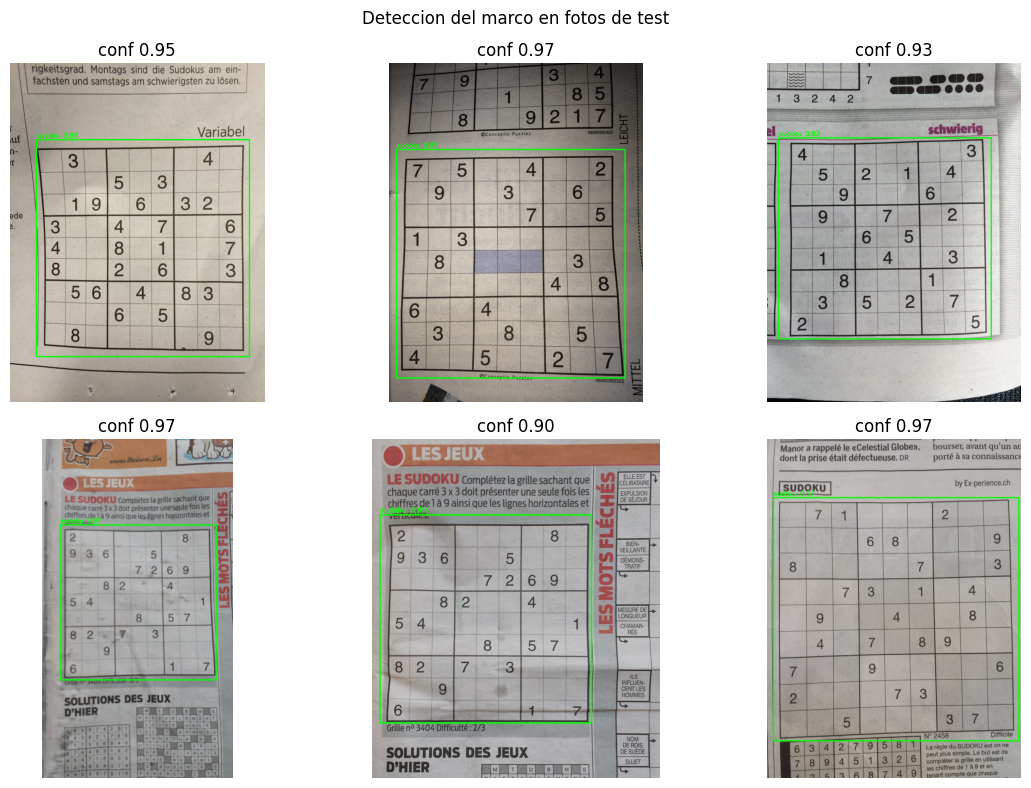

In [5]:
det = detector.SudokuDetector(weights=weights_path, device=DEVICE)
test_imgs = sorted(glob.glob(str(ROOT / "images/test/*.jpg")))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, p in zip(axes.ravel(), test_imgs[:6]):
    out, d = det.detect_and_draw(cv2.imread(p))
    title = f"conf {d[4]:.2f}" if d else "sin deteccion"
    show(out, title, ax)
plt.suptitle("Deteccion del marco en fotos de test"); plt.tight_layout(); plt.show()

## 5. Tasa de deteccion en todo el test

In [6]:
detectadas = 0
confs = []
for p in test_imgs:
    d = det.detect(cv2.imread(p))
    if d is not None:
        detectadas += 1
        confs.append(d[4])
print(f"Tableros detectados: {detectadas} / {len(test_imgs)}")
print(f"Confianza media: {np.mean(confs):.3f}")

Tableros detectados: 22 / 22
Confianza media: 0.961


## 6. Uso

Ya entrenado, el detector se usa asi en cualquier script:

```python
from detector import SudokuDetector
det = SudokuDetector()                 # carga models/sudoku_detector.pt
bbox = det.detect(cv2.imread('foto.jpg'))   # (x1, y1, x2, y2, confianza) o None
```

O por linea de comandos: `python src/detector.py foto.jpg` -> guarda `detected.png`.

Siguiente paso del proyecto: recortar/rectificar ese marco para leer los digitos.